In [1]:
## PDOS Summation
from pymatgen.io.vasp import Vasprun
from pymatgen.electronic_structure.core import Spin, Orbital
import numpy as np

v_lno = Vasprun("vasprun_lim10_lno.xml", parse_dos=True, parse_eigen=True)
v_lnfo = Vasprun("vasprun_lim10_lnfo.xml", parse_dos=True, parse_eigen=True)

def get_d_orbital_pdos(vasprun_obj):
    cdos = vasprun_obj.complete_dos
    structure = vasprun_obj.final_structure
    energies = cdos.energies - cdos.efermi

    # Ni, Fe 인덱스 찾기
    d_indices = [i for i, site in enumerate(structure) 
                 if site.specie.symbol in ["Fe", "Ni"]]
    
    t2g_list = [Orbital.dxy, Orbital.dyz, Orbital.dxz]
    eg_list = [Orbital.dz2, Orbital.dx2]
    
    t2g_up, t2g_down = np.zeros_like(energies), np.zeros_like(energies)
    eg_up, eg_down = np.zeros_like(energies), np.zeros_like(energies)

    for idx in d_indices:
        site = structure[idx]
        site_orb_dos = cdos.pdos[site]
        
        for orb in t2g_list:
            if orb in site_orb_dos:
                t2g_up += site_orb_dos[orb].get(Spin.up, 0)
                t2g_down += site_orb_dos[orb].get(Spin.down, 0)
        for orb in eg_list:
            if orb in site_orb_dos:
                eg_up += site_orb_dos[orb].get(Spin.up, 0)
                eg_down += site_orb_dos[orb].get(Spin.down, 0)
                
    return {
        'num_atoms': len(d_indices),
        'energies': energies,
        't2g_up': t2g_up,
        't2g_down' : t2g_down,
        'eg_up': eg_up,
        'eg_down' : eg_down,
        'eg_avg' : sum(eg_up + eg_down) / len(eg_up)
    }

data_lno = get_d_orbital_pdos(v_lno)  
data_lnfo = get_d_orbital_pdos(v_lnfo)

/home/sowon-laptop/anaconda3/envs/vscode/lib/python3.12/site-packages/pymatgen/io/vasp/outputs.py:1327: UserWarning: No POTCAR file with matching TITEL fields was found in

  if potcar := self.get_potcars(path):
/home/sowon-laptop/anaconda3/envs/vscode/lib/python3.12/site-packages/pymatgen/io/vasp/outputs.py:1338: UserWarning: No POTCAR file with matching TITEL fields was found in

  potcar = self.get_potcars(path)


Saved as PDOS_Stacked_Result.png.


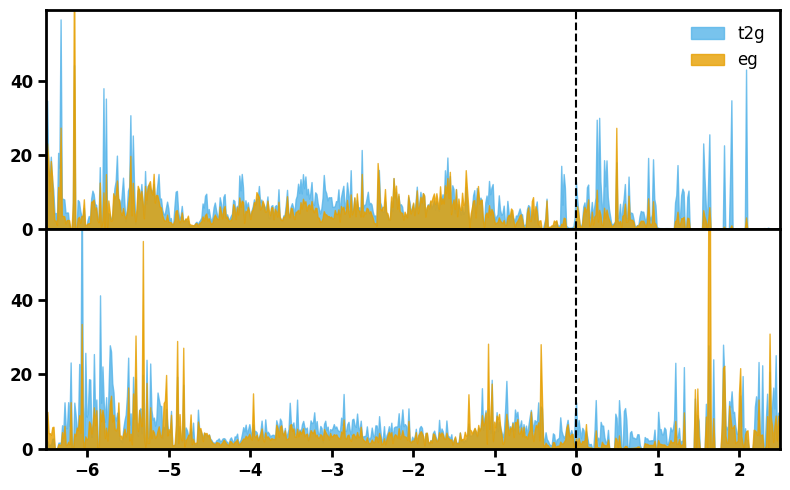

In [15]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from scipy.ndimage import gaussian_filter

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5), sharex=True, gridspec_kw={'hspace': 0})
axs = [ax1, ax2]

# --- 첫 번째 그래프 (Top) ---
ax1.fill_between(data_lno['energies'], data_lno['t2g_up']+data_lno['t2g_down'], color="#56B4E9", alpha=0.8, label='t2g')
ax1.fill_between(data_lno['energies'], data_lno['eg_up']+data_lno['eg_down'], color="#E69F00", alpha=0.8, label='eg')
#ax1.text(0.02, 0.85, "$LiNiO_2$", transform=ax1.transAxes, fontsize=14, fontweight='bold') # 라벨 추가

# --- 두 번째 그래프 (Bottom) ---
ax2.fill_between(data_lnfo['energies'], data_lnfo['t2g_up']+data_lnfo['t2g_down'], color="#56B4E9", alpha=0.8)
ax2.fill_between(data_lnfo['energies'], data_lnfo['eg_up']+data_lnfo['eg_down'], color="#E69F00", alpha=0.8)
#ax2.text(0.02, 0.85, "$LiNiFeO_2$", transform=ax2.transAxes, fontsize=14, fontweight='bold')

# 공통 스타일 설정
line_width = 2.0
for ax in axs:
    ax.axvline(0, color='black', linestyle='--', lw=1.5)
    ax.set_xlim(-6.5, 2.5)
    ax.set_ylim(0, 59)
    ax.yaxis.set_major_locator(MultipleLocator(20))

    # 테두리 두께 및 틱 설정
    for spine in ax.spines.values():
        spine.set_linewidth(line_width)
    ax.tick_params(axis='both', which='major', labelsize=12, width=line_width, length=6, )
    
    # 틱 폰트 굵게
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')

# 범례는 첫 번째 그래프에만 표시 (또는 원하는 곳에)
ax1.legend(frameon=False, fontsize=12, loc='upper right')

# x축 라벨은 맨 아래 그래프에만 표시
#ax2.set_xlabel('Energy (${E - E_F}$, eV)', fontsize=14, fontweight='bold')

# 레이아웃 조정 및 저장
plt.tight_layout()
img_name = "PDOS_Stacked_Result.png"
plt.savefig(img_name, dpi=300)
print(f"Saved as {img_name}.")
plt.show()

In [14]:
#test 
#    return {
    #     'num_atoms': len(d_indices),
    #     'energies': energies,
    #     't2g_up': t2g_up,
    #     't2g_down' : t2g_down,
    #     'eg_up': eg_up,
    #     'eg_down' : eg_down,
    #     'eg_avg' : sum(eg_up + eg_down) / len(eg_up)
    # }
from scipy.integrate import simpson

def orbital_occupancy_calculator(data_dict):
    energies = data_dict['energies']
    mask = energies <= 0
    occ_energies = energies[mask]
    t2g = data_dict['t2g_up'] + data_dict['t2g_down']
    eg = data_dict['eg_up'] + data_dict['eg_down']

    # 2. t2g & eg Integral area
    t2g_area = simpson(y=t2g[mask], x=occ_energies) / data_dict['num_atoms']
    eg_area = simpson(y=eg[mask], x=occ_energies)/ data_dict['num_atoms']
    eg_t2g_ratio = eg_area / t2g_area

    print("="*20)
    print(f"1. t2g average: {t2g_area:.4f}")
    print(f"2. eg average: {eg_area:.4f}")
    print(f"3. eg/t2g: {eg_t2g_ratio:.4f}")
    print("=" * 20 + "\n")

print("LiNiO2:")
orbital_occupancy_calculator(data_lno)
print("LiNiFeO2:")
orbital_occupancy_calculator(data_lnfo)

    # # 각 원자의 eg 점유율 리스트로 확인하기
    # individual_eg = []

    # for idx in d_index:
    #     site = v.final_structure[idx]
    #     site_orb_dos = cdos.pdos[site]
        
    #     # 해당 Ni의 eg 데이터만 추출
    #     single_eg_dos = np.zeros_like(energies)
    #     for orb in eg_list:
    #         if orb in site_orb_dos:
    #             if Spin.up in site_orb_dos[orb]:    
    #                 single_eg_dos += site_orb_dos[orb][Spin.up]
    #             if Spin.down in site_orb_dos[orb]:
    #                 single_eg_dos += site_orb_dos[orb][Spin.down]
        
    #     # 점유율 계산 (적분)
    #     mask = energies <= 0
    #     occ = simpson(y=single_eg_dos[mask], x=energies[mask])
        
    #     # 정규화 (d7 기준 비율 적용)
    #     # 개별 원자의 t2g도 구해야 정확하지만, 일단 단순 적분값으로 편차 확인
    #     individual_eg.append(occ)

    # print("Each Ni+Fe atoms eg integrated value:")
    # for i, val in enumerate(individual_eg):
    #     print(f"{d_index[i]}: {val:.4f}")

LiNiO2:
1. t2g average: 4.7834
2. eg average: 3.4933
3. eg/t2g: 0.7303

LiNiFeO2:
1. t2g average: 3.2262
2. eg average: 2.3427
3. eg/t2g: 0.7262

